In [4]:
# Install core Qiskit, the Aer simulator package, and visualization dependencies
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.4 MB/s eta 0:00:00:00:010:01
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=40b91a5a76896d4c8328b0328447d2299a459311a03b393cf8b57549329e551f
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


# Project 1: The Bell State
**Objective:** Master Qiskit syntax, initialize `QuantumCircuit` objects, and manipulate basic entanglement and probabilities.

**Theory:**
A Bell State is the simplest example of quantum entanglement. To create it, we use two gates:
1. **Hadamard Gate ($H$):** Puts the first qubit into a perfect superposition.
2. **CNOT Gate (Controlled-NOT):** Flips the second qubit *only if* the first qubit is a 1. 

Because the first qubit is in a superposition of 0 and 1, the CNOT gate forces the two qubits to become entangled. 

**Target Output State:** $$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$

In [5]:
# Import core Qiskit libraries and visualization tools
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler # Modern V2 execution primitive
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

print("Qiskit libraries imported successfully.")

Qiskit libraries imported successfully.


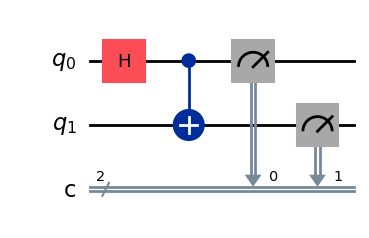

In [6]:
# 1. Initialize a QuantumCircuit with 2 qubits and 2 classical bits.
# Note: By default, Qiskit names the classical register 'c'.
qc = QuantumCircuit(2, 2)

# 2. Apply the Hadamard gate to Qubit 0
qc.h(0)

# 3. Apply the CNOT gate (Control = 0, Target = 1)
qc.cx(0, 1)

# 4. Measure both qubits and map the results to the classical bits
qc.measure([0, 1], [0, 1])

# 5. Visually verify the circuit architecture
qc.draw('mpl')

In [7]:
# 1. Initialize the modern V2 Sampler
sampler = StatevectorSampler()

# 2. Execute the circuit. 
# V2 primitives require inputs to be formatted as PUBs (Primitive Unified Blocs).
job = sampler.run([qc], shots=1000)
result = job.result()

# 3. Extract the result for the first (and only) PUB
pub_result = result[0]

# 4. Extract the counts from the classical register 'c' inside the data bin
counts = pub_result.data.c.get_counts()
print(f"Raw Measurement Counts: {counts}")

Raw Measurement Counts: {'00': 528, '11': 472}


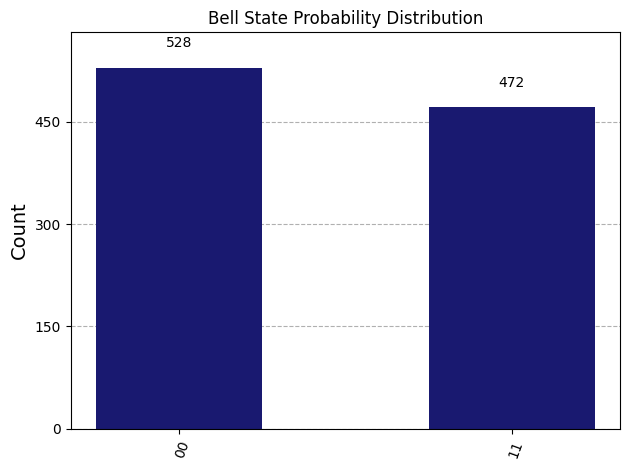

In [8]:
# Visualize the probability distribution
plot_histogram(counts, title="Bell State Probability Distribution", color='midnightblue')